In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from utils import (
    SyntheticLinearDataset, mu_f_linear,
    rademacher_linear_empirical, figures_dir
)

In [2]:
feature_sizes = np.unique(np.linspace(8, 128, num=12, dtype=int))
variance_tries = 16
seed = 42

mu_all = np.zeros((len(feature_sizes), variance_tries))
rad_all = np.zeros((len(feature_sizes), variance_tries))

for j, n in enumerate(tqdm(feature_sizes)):
    for t in range(variance_tries):
        ds = SyntheticLinearDataset(
            n=n,
            m=256,
            noise_std=0.1,
            seed=seed + t,
            row_radius_log_sigma=0.28,
        )
        X, _, _ = ds.sample()

        mu_all[j, t] = mu_f_linear(X)
        rad_all[j, t] = rademacher_linear_empirical(
            X, W=2.0, n_mc=4096, rng=np.random.default_rng(seed + t)
        )

mu_mean, mu_std = mu_all.mean(axis=1), mu_all.std(axis=1, ddof=1)
rad_mean, rad_std = rad_all.mean(axis=1), rad_all.std(axis=1, ddof=1)

  0%|          | 0/12 [00:00<?, ?it/s]

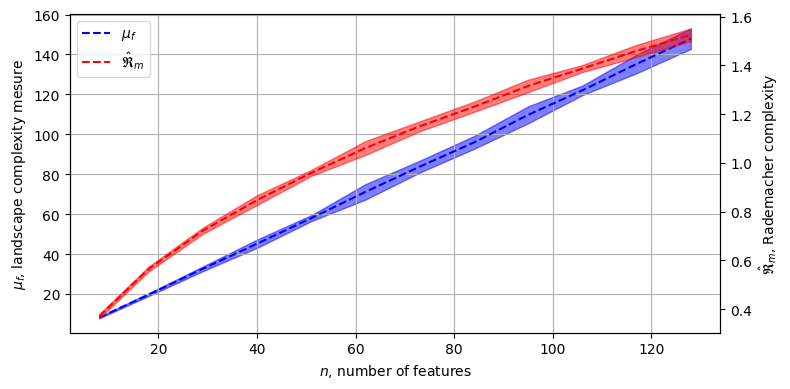

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.set_xlabel(r"$n$, number of features")
ax2 = ax1.twinx()

ax1.fill_between(
    feature_sizes, mu_mean - mu_std, mu_mean + mu_std,
    color="blue", alpha=0.5
)
ax1.plot(
    feature_sizes, mu_mean, "--",
    color="blue", label=r"$\mu_f$"
)
ax1.set_ylabel(r"$\mu_f$, landscape complexity mesure")
ax1.tick_params(axis="y")

ax2.fill_between(
    feature_sizes, rad_mean - rad_std, rad_mean + rad_std,
    color="red", alpha=0.5
)
ax2.plot(
    feature_sizes, rad_mean, ls="--",
    color="red", label=r"$\hat{\mathfrak{R}}_m$"
)
ax2.set_ylabel(r"$\hat{\mathfrak{R}}_m$, Rademacher complexity")
ax2.tick_params(axis="y")

ax1.grid(True)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, lab1 + lab2, loc="upper left"
)

fig.tight_layout()
fig.savefig(
    figures_dir() / "exp01_linear_sweep_n.png", dpi=200, bbox_inches="tight"
)

plt.show()